In [38]:
from cuda_cqed.sim import Sim
# import gpu_odes.HatGPUODE_D
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Qt5Agg')
%matplotlib inline

The Hamiltonian for squeezing in the rotating frame is generally defined 
$$
H_{sqz} = g_2(e^{i \omega_p t} a a + e^{-i \omega_p t} a^{\dagger} a^{\dagger} ) + \Delta a^{\dagger} a 
$$
To get a good description of this system, we need the cumulant expansion to 2nd order (linear squeezing). So we get the Heisenberg equations of motion

$$
\dot{a}  = -2 i g_2 a^{\dagger} e^{-i \omega_p t} - i \Delta a
$$
$$
\dot{aa}  = -4 i g_2 a^{\dagger} a e^{-i \omega_p t} - 2 i g_2  e^{-i \omega_p t} - 2 i \Delta a a
$$
$$
\dot{a^{\dagger} a}  = -2 i g_2 a^{\dagger} a^{\dagger} e^{-i \omega_p t} + 2 g_2 a a e^{i \omega_p t}
$$

Here we can take expectation values to get an exact closed system of ODEs.

$$
\dot{\langle a \rangle} = -2 i g_2 \langle a^{\dagger} \rangle e^{-i \omega_p t} - i \Delta \langle a \rangle
$$
$$
\dot{\langle aa \rangle}  = -4 i g_2 \langle a^{\dagger} a \rangle e^{-i \omega_p t}  - 2 i g_2  e^{-i \omega_p t} - 2 i \Delta \langle a a \rangle
$$
$$
\dot{\langle a^{\dagger} a \rangle}  = -2 i g_2 \langle a a \rangle^{\dagger} e^{-i \omega_p t} + 2 i g_2 \langle a a \rangle e^{i \omega_p t}
$$


# todo
why does $\dot{\langle a \rangle}$ need a flipped sign of the phase to work?

In [107]:
disp = 2
g2 = 15*2*np.pi
phi = np.pi/2
Delta = 50*2*np.pi
omega_p = 0*2*np.pi

In [115]:
pi = np.pi

sim = Sim(use_complex=True)

sim.add_param('Delta', Delta, is_excitation=True)
sim.add_paramsweep('g2', 0, 2*g2, 101)
sim.add_param('phi', phi)
sim.add_param('omega_p', omega_p)
sim.add_param('IC', disp)

# sim.add_EOM('a', '-2j*g2*conjugate(a)*exp(-1j*phi) - 1j*Delta*a',IC_str='IC')
# sim.add_EOM('a_a', '-4j*g2*adag_a*exp(-1j*phi) - 2j*g2*exp(-1j*phi) - 2j*Delta*a_a', IC_str='IC**2')
# sim.add_EOM('adag_a', '-2j*g2*adag_adag*exp(-1j*phi) + 2j*g2*a_a*exp(1j*phi)',IC_str='abs(IC)**2')
# sim.add_EOM('adag_adag', '4j*g2*adag_a*exp(-1j*phi) + 2j*g2*exp(-1j*phi) + 2j*Delta*adag_adag', IC_str='IC**2')


sim.add_EOM('a', '2j*g2*conjugate(a)*exp(-1j*(omega_p*t-phi)) - 1j*Delta*a',IC_str='IC')
# sim.add_EOM('aa', '0',IC_str='IC')
# sim.add_EOM('na', '0',IC_str='IC')
sim.add_EOM('aa', '-4j*g2*na*exp(-1j*(omega_p*t+phi)) - 2j*g2*exp(-1j*(omega_p*t+phi)) - 2j*Delta*aa', IC_str='IC**2')
sim.add_EOM('na', '-2j*g2*conjugate(aa)*exp(-1j*(omega_p*t+phi))+2j*g2*aa*exp(1j*(omega_p*t+phi))',IC_str='abs(IC)**2')

sim.set_solve_type('all')

sim.specify_time(t_f=0.03, pts=10001)

sim.validate(print_result=False)

Recent change to specify_time(), check implementation
Simulation validation success!


In [116]:
x, t = sim.quick_trace()

Simulation validation success!
Running CPU quick solve...
...finished CPU quick solve!


In [117]:
b = x[0,:]+1j*x[1,:]
bb = x[2,:]+1j*x[3,:]
nb = x[4,:]+1j*x[5,:]

In [118]:
def plot_Qfunc(a, aa, na, ax=None, plot_arg=None):

    if ax == None:
        ax = plt.gca()
    
    ad = np.conjugate(a)
    adad = np.conjugate(aa)
    sxx = 1/2 + 1/2*( (aa - a*a) + 2*(na - ad*a) + (adad - ad*ad))
    syy = 1/2 - 1/2*( (aa - a*a) - 2*(na - ad*a) + (adad - ad*ad))
    sxy = np.imag(1/2*((aa - a*a) - (adad - ad*ad)))
    covar =  np.real(np.array([[sxx, sxy], [sxy, syy]]))

    print(covar)
    print(' ')

    phi = np.linspace(0, 2*np.pi, 101)
    
    print(np.argsort(np.linalg.eig(covar)[0]))

    order = np.argsort(np.linalg.eig(covar)[0])
    major_idx = order[1]
    minor_idx = order[0]
    
    theta = -np.angle(np.linalg.eig(covar)[1][:,1][minor_idx]+1j*np.linalg.eig(covar)[1][:,1][major_idx])
    Smajor = np.sort(np.linalg.eig(covar)[0])[major_idx]
    Sminor = np.sort(np.linalg.eig(covar)[0])[minor_idx]
    
    x1 = np.sqrt(Smajor)*np.cos(phi)*2
    y1 = np.sqrt(Sminor)*np.sin(phi)*2
    
    x2 = x1*np.cos(theta) + y1*np.sin(theta) + np.real(a)
    y2 = -x1*np.sin(theta) + y1*np.cos(theta) + np.imag(a)

    if plot_arg == None:
        ax.plot(x2,y2)
    else:
        ax.plot(x2,y2,plot_arg)
    # ax.xlim([-7,7])
    # ax.ylim([-7,7])
    # plt.gca().set_aspect('equal')
    # plt.grid()
    # plt.show()

    

In [119]:
# from cuda_cqed.cumulant_plot.cumulant_slider_plot import cumulant_slider_plot
# %matplotlib qt
# x, t = sim.solve()



In [120]:
# xd = x.copy()
# td = t.copy()

# b = x[0, :] + 1j * x[1, :]
# bb = x[2, :] + 1j * x[3, :]
# nb = x[4, :] + 1j * x[5, :]

# axes_dict = {'g2': sim.paramsweep_dict['g2'], 'time ': t[0,:]}

# plt.close('all')
# cumulant_slider_plot(b, bb, nb, axes_dict, plot_range=20)
# plt.show()

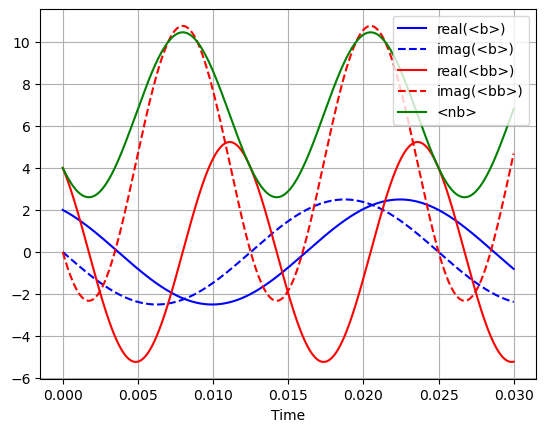

In [121]:
tlist = np.unique(t)
plt.plot(tlist, np.real(b),'b-',label='real(<b>)')
plt.plot(tlist, np.imag(b),'b--',label='imag(<b>)')
plt.plot(tlist, np.real(bb),'r-',label='real(<bb>)')
plt.plot(tlist, np.imag(bb),'r--',label='imag(<bb>)')
plt.plot(tlist, np.real(nb),'g',label='<nb>')
plt.legend()
plt.grid()
plt.xlabel('Time')
plt.show()

# QuTiP version

In [122]:
from base64 import b64encode

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML
from matplotlib import animation
from qutip import (about, basis, coherent, destroy, displace, expect, mesolve,
                   num, plot_fock_distribution, plot_wigner, squeeze, variance, Options)

%matplotlib inline

In [123]:
N = 100

# operators
a = destroy(N)
n = num(N)
x = (a + a.dag()) / np.sqrt(2)
p = -1j * (a - a.dag()) / np.sqrt(2)

eta = g2*np.exp(-1j*(omega_p*tlist+phi))

H0 = Delta*a.dag()*a

H = [H0, [a.dag()*a.dag(), eta],[a*a, np.conjugate(eta)]]

c_ops = [0.0*a]

In [124]:
def plot_expect_with_variance(N, op_list, op_title, states):
    """
    Plot the expectation value of an operator (list of operators)
    with an envelope that describes the operators variance.
    """

    fig, axes = plt.subplots(1, len(op_list), figsize=(14, 3))

    for idx, op in enumerate(op_list):

        e_op = expect(op, states)
        v_op = variance(op, states)

        axes[idx].fill_between(
            tlist, e_op - np.sqrt(v_op), e_op + np.sqrt(v_op), color="green",
            alpha=0.5)
        axes[idx].plot(tlist, e_op, label="expectation")
        axes[idx].set_xlabel("Time")
        axes[idx].set_title(op_title[idx])

    return fig, axes

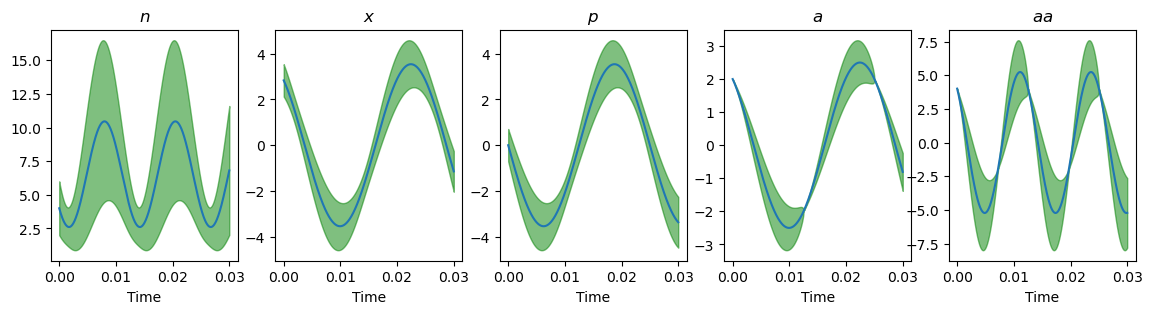

In [125]:
psi0 = coherent(N, disp)

result = mesolve(H, psi0, t, c_ops, [])

plot_expect_with_variance(N, [n, x, p, a, a*a], [r"$n$", r"$x$", r"$p$",  r"$a$",  r"$aa$"],
                          result.states);
plt.show()

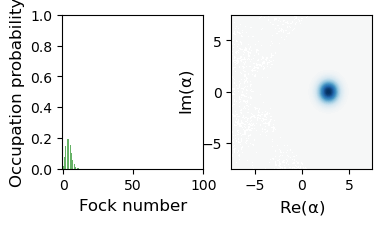

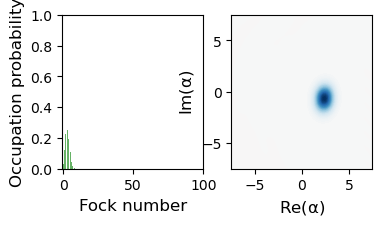

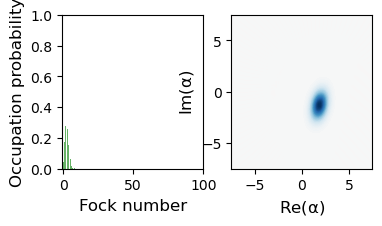

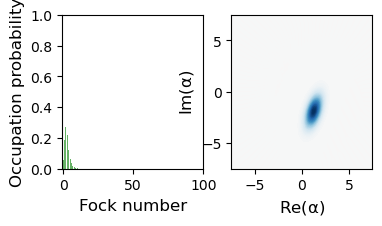

In [126]:
# i = 0

# fig, axes = plt.subplots(1, 2, figsize=(10, 5))
# axes[0].cla()
# plot_fock_distribution(result.states[i], fig=fig, ax=axes[0])
# plot_wigner(result.states[i], fig=fig, ax=axes[1])
# plt.show()

i = 0

fig, axes = plt.subplots(1, 2, figsize=(4, 2))
axes[0].cla()
plot_fock_distribution(result.states[i], fig=fig, ax=axes[0])
plot_wigner(result.states[i], fig=fig, ax=axes[1])
plt.show()

i = 250

fig, axes = plt.subplots(1, 2, figsize=(4, 2))
axes[0].cla()
plot_fock_distribution(result.states[i], fig=fig, ax=axes[0])
plot_wigner(result.states[i], fig=fig, ax=axes[1])
plt.show()

i = 500

fig, axes = plt.subplots(1, 2, figsize=(4, 2))
axes[0].cla()
plot_fock_distribution(result.states[i], fig=fig, ax=axes[0])
plot_wigner(result.states[i], fig=fig, ax=axes[1])
plt.show()

i = 750

fig, axes = plt.subplots(1, 2, figsize=(4, 2))
axes[0].cla()
plot_fock_distribution(result.states[i], fig=fig, ax=axes[0])
plot_wigner(result.states[i], fig=fig, ax=axes[1])
plt.show()

In [ ]:
plt.figure(figsize=(10,7))
plt.plot(t,np.real(expect(a, result.states)),'r-',label='real(<a>)',linewidth=3)
plt.plot(t,np.imag(expect(a, result.states)),'g-',label='imag(<a>)',linewidth=2.5)
plt.plot(t,np.real(expect(a*a, result.states)),'b-',label='real(<aa>)',linewidth=2)
plt.plot(t,np.imag(expect(a*a, result.states)),'m-',label='imag(<aa>)',linewidth=1.5)
plt.plot(t,expect(a.dag()*a, result.states),'k-',label='<n>',linewidth=1)

plt.plot(t,np.real(b),'r--',label='real(<b>) (cumulant)',linewidth=3)
plt.plot(t,np.imag(b),'g--',label='imag(<b>) (cumulant)',linewidth=2.5)
plt.plot(t,np.real(bb),'b--',label='real(<bb>) (cumulant)',linewidth=2)
plt.plot(t,np.imag(bb),'m--',label='imag(<bb>) (cumulant)',linewidth=1.5)
plt.plot(t,np.real(nb),'k--',label='<nb> (cumulant)',linewidth=1)
# plt.xlim([0,30])
# plt.ylim([-0.1,0.1])
plt.legend()
plt.grid()
plt.xlabel('Time')
plt.show()